In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/mricardo89/data-mining/main/Unit-II/datasets/titanic.csv"
df = pd.read_csv(url)

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
mujeres = df[df["Sex"] == "female"]
hombres = df[df["Sex"] == "male"]

print("Mujeres:", len(mujeres), "pasajeras | tarifa promedio:", mujeres["Fare"].mean())
print("Hombres:", len(hombres), "pasajeros | tarifa promedio:", hombres["Fare"].mean())

df.groupby('Sex')['Fare'].mean()

Mujeres: 314 pasajeras | tarifa promedio: 44.47981783439491
Hombres: 577 pasajeros | tarifa promedio: 25.523893414211443


Sex
female    44.479818
male      25.523893
Name: Fare, dtype: float64

# Preguntas de análisis

### ¿Cuál fue la tarifa promedio que pagaron las mujeres?

**44.48** (314 pasajeras).

### ¿Y cuál fue la de los hombres?

**25.52** (577 pasajeros).

In [ ]:
q1 = df["Fare"].quantile(0.25)
q3 = df["Fare"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print("Q1:", q1, "| Q3:", q3, "| IQR:", iqr)
print("Limite inferior:", limite_inferior, "| Limite superior:", limite_superior)

outliers = df[(df["Fare"] < limite_inferior) | (df["Fare"] > limite_superior)]

print("\nOutliers encontrados:", len(outliers), "de", len(df))
print(outliers[["Name", "Sex", "Pclass", "Fare"]].sort_values("Fare", ascending=False))

Q1: 7.9104 | Q3: 31.0 | IQR: 23.0896
Limite inferior: -26.724 | Limite superior: 65.6344

Outliers encontrados: 116 de 891
                                   Name     Sex  Pclass      Fare
679  Cardeza, Mr. Thomas Drake Martinez    male       1  512.3292
258                    Ward, Miss. Anna  female       1  512.3292
737              Lesurer, Mr. Gustave J    male       1  512.3292
341      Fortune, Miss. Alice Elizabeth  female       1  263.0000
438                   Fortune, Mr. Mark    male       1  263.0000
..                                  ...     ...     ...       ...
324            Sage, Mr. George John Jr    male       3   69.5500
369       Aubart, Mme. Leontine Pauline  female       1   69.3000
641                Sagesser, Mlle. Emma  female       1   69.3000
151   Pears, Mrs. Thomas (Edith Wearne)  female       1   66.6000
336           Pears, Mr. Thomas Clinton    male       1   66.6000

[116 rows x 4 columns]


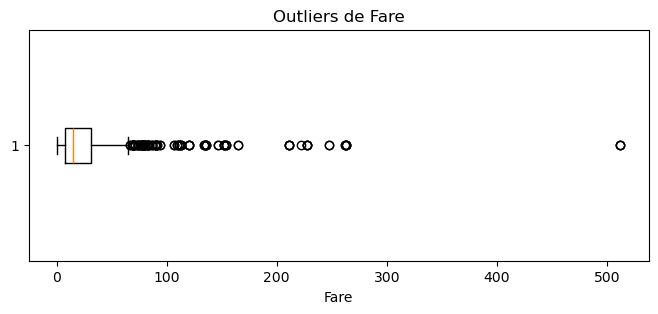

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.boxplot(df["Fare"], orientation="horizontal")
plt.title("Outliers de Fare")
plt.xlabel("Fare")
plt.show()

In [ ]:
print("Tasa de supervivencia global:", df["Survived"].mean())
print("Mujeres que sobrevivieron:", mujeres["Survived"].mean())
print("Hombres que sobrevivieron:", hombres["Survived"].mean())

print("\nOutliers por clase:")
print(outliers["Pclass"].value_counts())

### ¿Cuál fue la tasa de supervivencia global del barco expresada en porcentaje?

**38.38%** sobrevivió (murió el 61.62% de los 891 pasajeros).

### ¿Qué porcentaje exacto de mujeres sobrevivió en contraste con los hombres?

**74.20%** de las mujeres contra **18.89%** de los hombres — una mujer tenía 3.9 veces más probabilidad de sobrevivir.

### ¿A qué clase pertenecían la mayoría de outliers?

A **primera clase: 104 de los 116 outliers (89.7%)**. Los otros 12 se reparten entre tercera (7) y segunda (5).